## Score: 28

## Comment: 

<font color=Red>
Q1.[7] Symbolization, topographic map, central meridian are incorrect
<br><br>
Q2.[11+10] Good job!
<br><br>
</font>

/var/folders/x8/8y9n4rkd2_g5631mlytyr71r0000gn/T/ipykernel_62942/470127885.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('plasma')
/opt/anaconda3/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


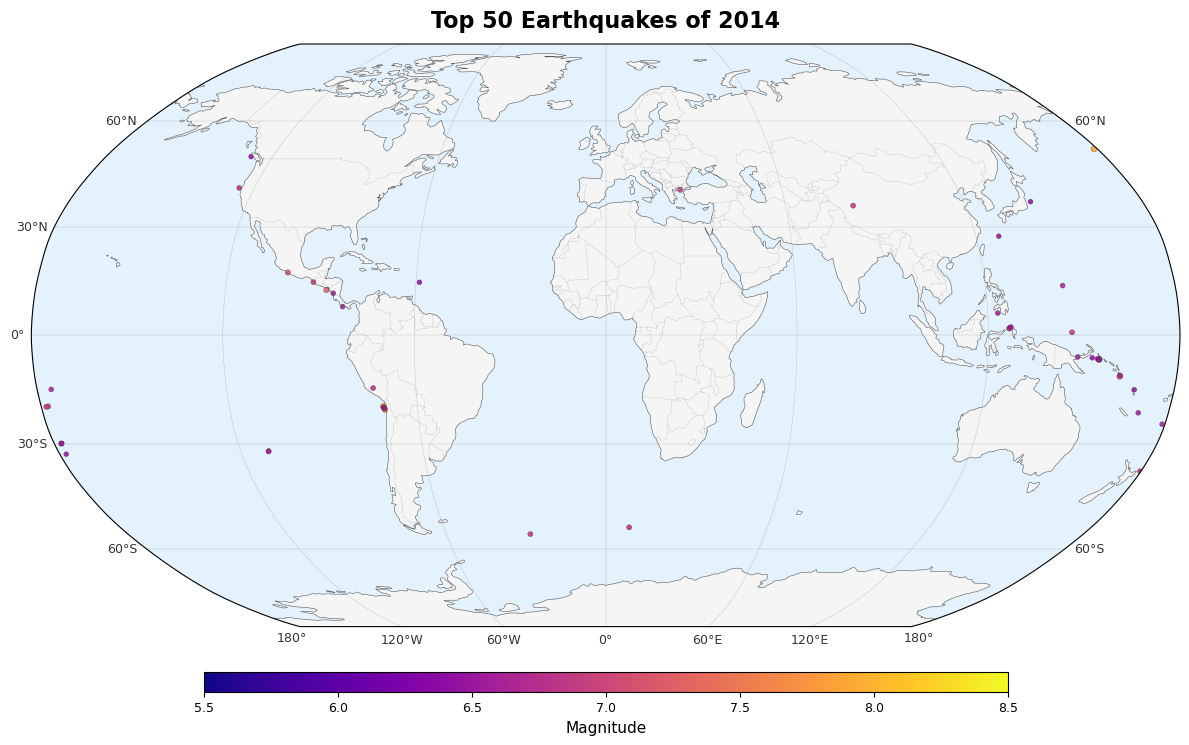

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

def plot_top50_2014():
    try:
        df = pd.read_csv('usgs_earthquakes.csv')
    except FileNotFoundError:
        print("错误：找不到 usgs_earthquakes.csv 文件，请确保文件在当前目录下。")
        return

    df = df.sort_values('mag', ascending=False).head(50)

    lats = df['latitude'].values
    lons = df['longitude'].values
    mags = df['mag'].values

    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.Robinson())
    ax.set_global()

    ax.add_feature(cfeature.LAND, facecolor='#F5F5F5', linewidth=0)
    ax.add_feature(cfeature.OCEAN, facecolor='#E3F2FD')
    ax.add_feature(cfeature.COASTLINE, edgecolor='#555555', linewidth=0.4)
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='#777777', linewidth=0.3)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3,
                      color='#999999', alpha=0.6, linestyle='-')
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = {'size': 9, 'color': '#333333'}
    gl.ylabel_style = {'size': 9, 'color': '#333333'}

    scale = 28 / (8.2 ** 2)  
    sizes = (mags ** 2) * scale * 72 / fig.dpi  # 转 points

    cmap = plt.cm.get_cmap('plasma')
    norm = plt.Normalize(vmin=5.5, vmax=8.5)
    colors = cmap(norm(mags))

    scatter = ax.scatter(lons, lats, s=sizes, c=colors,
                         transform=ccrs.PlateCarree(),
                         edgecolor='black', linewidth=0.15, alpha=0.9)

    plt.title('Top 50 Earthquakes of 2014', fontsize=16, pad=12, weight='bold')

    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                        ax=ax, orientation='horizontal',
                        pad=0.06, shrink=0.7, aspect=40)
    cbar.set_label('Magnitude', fontsize=11)
    cbar.set_ticks([5.5, 6, 6.5, 7, 7.5, 8, 8.5])
    cbar.ax.tick_params(labelsize=9)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_top50_2014()

In [7]:
import xarray as xr

# 打开你的 netCDF 文件
ds = xr.open_dataset('precip.mon.mean.nc')

# 打印数据集信息
print(ds.info())

xarray.Dataset {
dimensions:
	time = 561 ;
	nv = 2 ;
	lat = 72 ;
	lon = 144 ;

variables:
	datetime64[ns] time_bnds(time, nv) ;
		time_bnds:comment = time bounds for each time value ;
	float32 lat_bnds(lat, nv) ;
		lat_bnds:units = degrees_north ;
		lat_bnds:comment = latitude values at the north and south bounds of each pixel. ;
	float32 lon_bnds(lon, nv) ;
		lon_bnds:units = degrees_east ;
		lon_bnds:comment = longitude values at the west and east bounds of each pixel. ;
	float32 precip(time, lat, lon) ;
		precip:long_name = Average Monthly Rate of Precipitation ;
		precip:valid_range = [  0. 100.] ;
		precip:units = mm/day ;
		precip:precision = 32767 ;
		precip:var_desc = Precipitation ;
		precip:dataset = GPCP Version 2.3 Combined Precipitation Dataset ;
		precip:level_desc = Surface ;
		precip:statistic = Mean ;
		precip:parent_stat = Mean ;
		precip:actual_range = [0.000000e+00 1.365714e+13] ;
	float32 lat(lat) ;
		lat:units = degrees_north ;
		lat:actual_range = [ 88.75 -88.75]

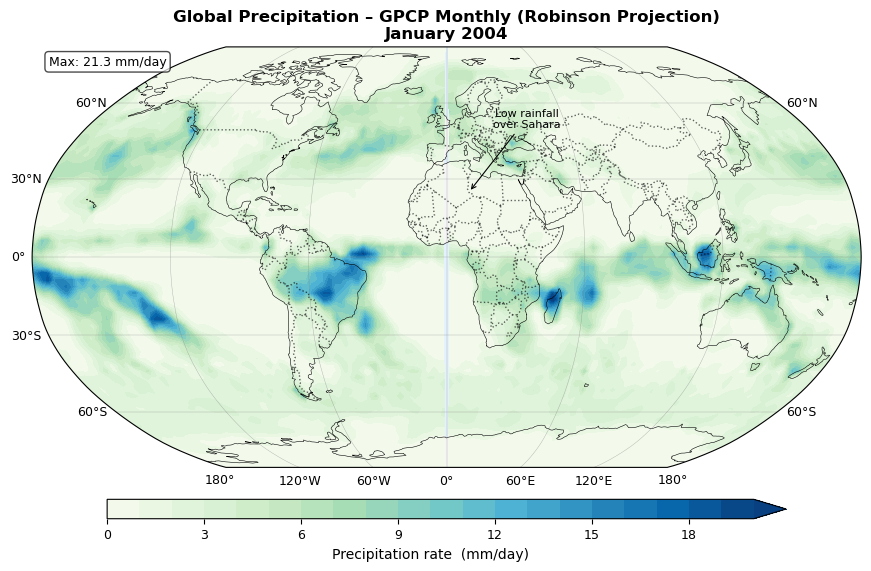

/opt/anaconda3/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/anaconda3/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/anaconda3/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/anaconda3/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


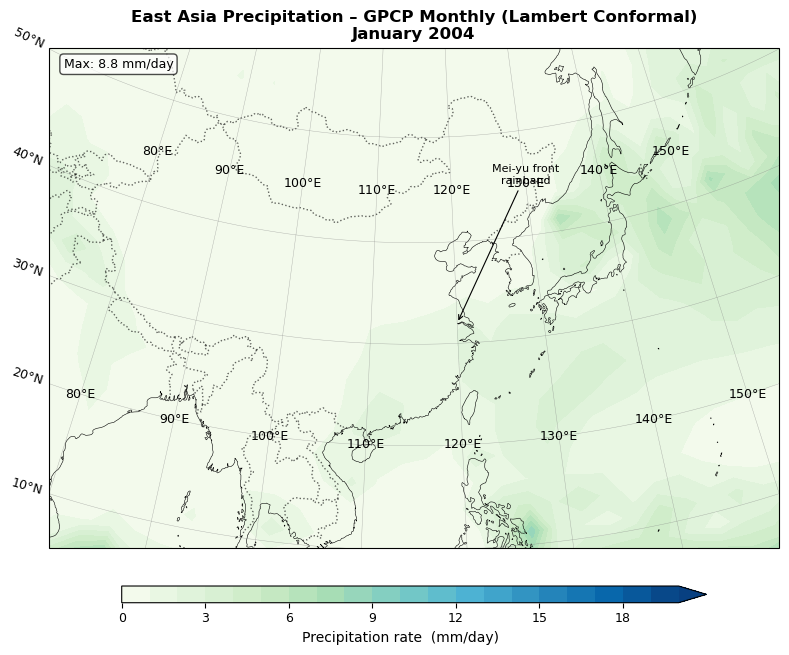

In [9]:

import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeat
import matplotlib.pyplot as plt
import numpy as np
import cartopy.mpl.ticker as cticker

ds   = xr.open_dataset('precip.mon.mean.nc')
t_idx = 300                                        
pr    = ds['precip'].isel(time=t_idx)              
lon   = pr.lon
lat   = pr.lat

#2.1 全球地图
proj_glob = ccrs.Robinson(central_longitude=0)
fig1 = plt.figure(figsize=(10, 6))
ax1  = fig1.add_subplot(111, projection=proj_glob)
ax1.set_global()

ax1.add_feature(cfeat.LAND, facecolor='#F5F5F5', linewidth=0)
ax1.add_feature(cfeat.OCEAN, facecolor='#E3F2FD')
ax1.add_feature(cfeat.COASTLINE, linewidth=0.4)
ax1.add_feature(cfeat.BORDERS, linestyle=':', alpha=0.6)

gl1 = ax1.gridlines(draw_labels=True, linewidth=0.3,
                    xlocs=np.arange(-180,181,60),
                    ylocs=np.arange(-60,61,30),
                    color='gray', alpha=0.6, linestyle='-')
gl1.top_labels   = False
gl1.right_labels = False
gl1.xlabel_style = {'size': 9}
gl1.ylabel_style = {'size': 9}

levels = np.linspace(0, 20, 21)   
cmap   = plt.cm.GnBu
cf1 = ax1.contourf(lon, lat, pr, levels=levels, cmap=cmap,
                   transform=ccrs.PlateCarree(), extend='max')

cbar1 = fig1.colorbar(cf1, ax=ax1, orientation='horizontal',
                      pad=0.06, shrink=0.7, aspect=35)
cbar1.set_label('Precipitation rate  (mm/day)', fontsize=10)
cbar1.ax.tick_params(labelsize=9)

ax1.set_title('Global Precipitation – GPCP Monthly (Robinson Projection)\n'
              f'{pr.time.dt.strftime("%B %Y").item()}',
              fontsize=12, weight='bold')

ax1.text(0.02, 0.98, f'Max: {pr.max().item():.1f} mm/day',
         transform=ax1.transAxes, ha='left', va='top',
         bbox=dict(boxstyle='round', facecolor='w', alpha=0.7),
         fontsize=9)
ax1.annotate('Low rainfall\nover Sahara', xy=(10, 25),
             xycoords=ccrs.PlateCarree()._as_mpl_transform(ax1),
             xytext=(40, 50), textcoords=ccrs.PlateCarree()._as_mpl_transform(ax1),
             arrowprops=dict(arrowstyle='->', color='k', lw=0.8),
             fontsize=8, ha='center')

plt.tight_layout()
plt.show()

#2.2 区域地图（东亚）
proj_reg = ccrs.LambertConformal(central_longitude=115,
                                 central_latitude=30,
                                 standard_parallels=(20, 40))
fig2 = plt.figure(figsize=(8, 7))
ax2  = fig2.add_subplot(111, projection=proj_reg)
ax2.set_extent([80, 150, 10, 55], crs=ccrs.PlateCarree())  

ax2.add_feature(cfeat.LAND.with_scale('50m'), facecolor='#F5F5F5', linewidth=0.3)
ax2.add_feature(cfeat.OCEAN.with_scale('50m'), facecolor='#E3F2FD')
ax2.add_feature(cfeat.COASTLINE.with_scale('50m'), linewidth=0.4)
ax2.add_feature(cfeat.BORDERS.with_scale('50m'), linestyle=':', alpha=0.6)

gl2 = ax2.gridlines(draw_labels=True, linewidth=0.3,
                    xlocs=np.arange(80, 151, 10),
                    ylocs=np.arange(10, 56, 10),
                    color='gray', alpha=0.6, linestyle='-')
gl2.top_labels   = False
gl2.right_labels = False
gl2.xlabel_style = {'size': 9}
gl2.ylabel_style = {'size': 9}

ax2.set_xlabel('Longitude', fontsize=10)
ax2.set_ylabel('Latitude', fontsize=10)

cf2 = ax2.contourf(lon, lat, pr, levels=levels, cmap=cmap,
                   transform=ccrs.PlateCarree(), extend='max')

cbar2 = fig2.colorbar(cf2, ax=ax2, orientation='horizontal',
                      pad=0.06, shrink=0.8, aspect=35)
cbar2.set_label('Precipitation rate  (mm/day)', fontsize=10)
cbar2.ax.tick_params(labelsize=9)

ax2.set_title('East Asia Precipitation – GPCP Monthly (Lambert Conformal)\n'
              f'{pr.time.dt.strftime("%B %Y").item()}',
              fontsize=12, weight='bold')

ax2.text(0.02, 0.98, f'Max: {pr.sel(lat=slice(10, 55), lon=slice(80, 150)).max().item():.1f} mm/day',
         transform=ax2.transAxes, ha='left', va='top',
         bbox=dict(boxstyle='round', facecolor='w', alpha=0.7),
         fontsize=9)
ax2.annotate('Mei-yu front\nrainband', xy=(120, 32),
             xycoords=ccrs.PlateCarree()._as_mpl_transform(ax2),
             xytext=(130, 45), textcoords=ccrs.PlateCarree()._as_mpl_transform(ax2),
             arrowprops=dict(arrowstyle='->', color='k', lw=0.8),
             fontsize=8, ha='center')

plt.tight_layout()
plt.show()